Time Series Forecasting:
Predicting the number of passengers book ticket for plane


In [2]:
%pip install -q statsmodels

Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import(
    mean_absolute_error,
    mean_squared_error,
    mean_squared_error,
    root_mean_squared_error
)


In [5]:
df=pd.read_csv("airline-passengers.csv")
print("Dataset Shape:",df.shape)
display(df.head(10))
df.tail(10)

Dataset Shape: (144, 2)


,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121
5,1949-06,135
6,1949-07,148
7,1949-08,148
8,1949-09,136
9,1949-10,119


,Month,Passengers
134,1960-03,419
135,1960-04,461
136,1960-05,472
137,1960-06,535
138,1960-07,622
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390
143,1960-12,432


In [6]:
df.isnull().sum()

Month         0
Passengers    0
dtype: int64

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Month       144 non-null    str  
 1   Passengers  144 non-null    int64
dtypes: int64(1), str(1)
memory usage: 2.4 KB


In [8]:
df.describe()

,Passengers
count,144.000000
mean,280.298611
std,119.966317
min,104.000000
25%,180.000000
50%,265.500000
75%,360.500000
max,622.000000


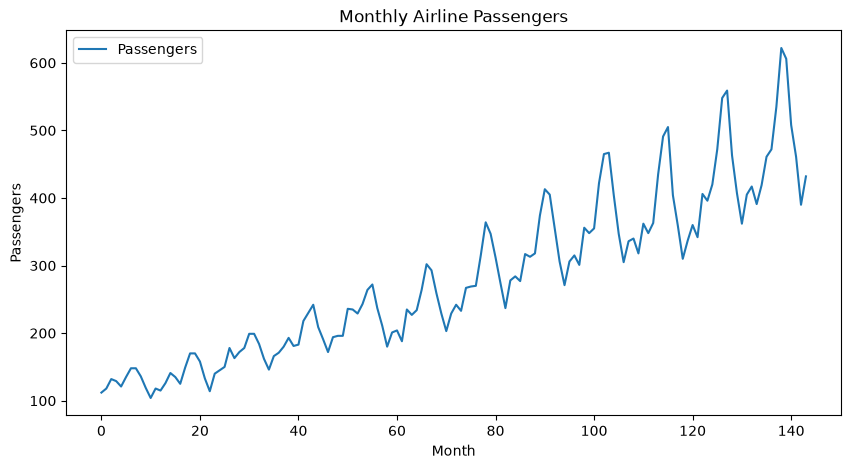

In [9]:
#plot time series
plt.figure(figsize=(10,5))
plt.plot(df["Passengers"],label="Passengers")
plt.title("Monthly Airline Passengers")
plt.ylabel("Passengers")
plt.xlabel("Month")
plt.legend()
plt.show()

Inference:Seasonality is clearly visible from the plot

In [10]:
result=adfuller(df["Passengers"])
p_value=result[1]
adf_value=result[0]
print(f"P value:{p_value:.3f}")
print(f"ADF stat: {adf_value:.3f}")


P value:0.992
ADF stat: 0.815


Null Hypothesis (H0) -> The data is non-stationary(seasonal)
Alternate Hypothesis (H1) -> The data is stationary(non-seasonal)
High p value shows the data is non-stationary,Hence transformations like differencing and decomposition are needed

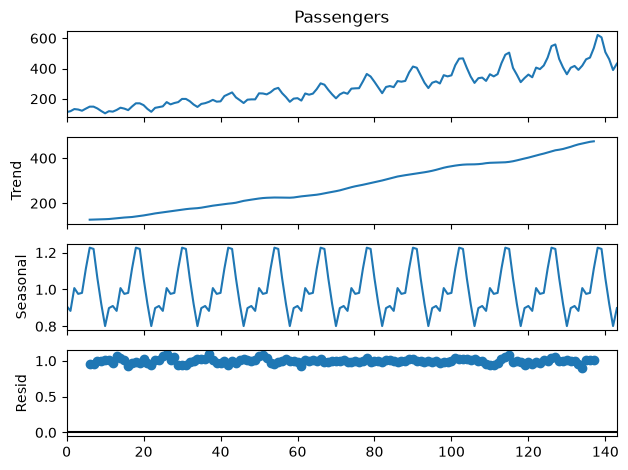

In [12]:
decomp=seasonal_decompose(
    df["Passengers"],
    model="multiplicative",
    period=12
)
decomp.plot()
plt.show()

In [13]:
#decomposition lets us know trend of the data,error ans seasonality
train=df.iloc[:-12] #extract all the rows except last 12 rows
test=df.iloc[-12:]

In [15]:
test

,Month,Passengers
132,1960-01,417
133,1960-02,391
134,1960-03,419
135,1960-04,461
136,1960-05,472
137,1960-06,535
138,1960-07,622
139,1960-08,606
140,1960-09,508
141,1960-10,461


In [17]:
train

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121
...,...,...
127,1959-08,559
128,1959-09,463
129,1959-10,407
130,1959-11,362


In [18]:
#train arima model
model=ARIMA(train["Passengers"],order=[5,1,0])
trained_model=model.fit()

In [19]:
forecast=trained_model.forecast(steps=12)

In [20]:
print(forecast)

132    458.449443
133    479.570529
134    480.136846
135    456.665326
136    435.835308
137    431.734529
138    437.928972
139    448.935482
140    455.562126
141    454.628434
142    450.095383
143    445.706017
Name: predicted_mean, dtype: float64


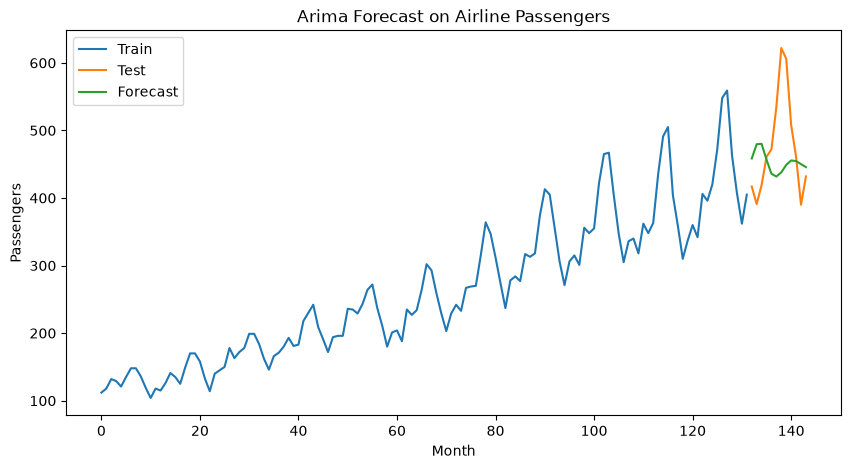

In [25]:
plt.figure(figsize=(10,5))
plt.plot(train.index,train["Passengers"],label="Train")
plt.plot(test.index,test["Passengers"],label="Test")
plt.plot(test.index,forecast,label="Forecast")
plt.title("Arima Forecast on Airline Passengers")
plt.xlabel("Month")
plt.ylabel("Passengers")
plt.legend()
plt.show()


In [26]:
mse=mean_squared_error(test['Passengers'],forecast)
mae=mean_absolute_error(test["Passengers"],forecast)
rmse=root_mean_squared_error(test["Passengers"],forecast)
print(f"MSE: {mse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")


MSE: 7536.00
MAE: 67.39
RMSE: 86.81


In [28]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [33]:
train_log=np.log(train["Passengers"])
test_log=np.log(test["Passengers"])


In [34]:
sarimax_model=SARIMAX(train_log,order=[1,1,1],
seasonal_order=(1,1,1,12))
trained_sarimax_model=sarimax_model.fit(display=False,maxiter=200)

c:\Users\tarak\OneDrive\Desktop\ds\.venv\Lib\site-packages\statsmodels\base\optimizer.py:21: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method lbfgs is: m, pgtol, factr, maxfun, epsilon, approx_grad, bounds, loglike_and_score, iprint. The list of unsupported keyword arguments passed include: display. After release 0.14, this will raise.
  warnings.warn(


In [35]:
forecast_log=trained_sarimax_model.forecast(steps=12)
forecast_sarimax=np.exp(forecast_log)

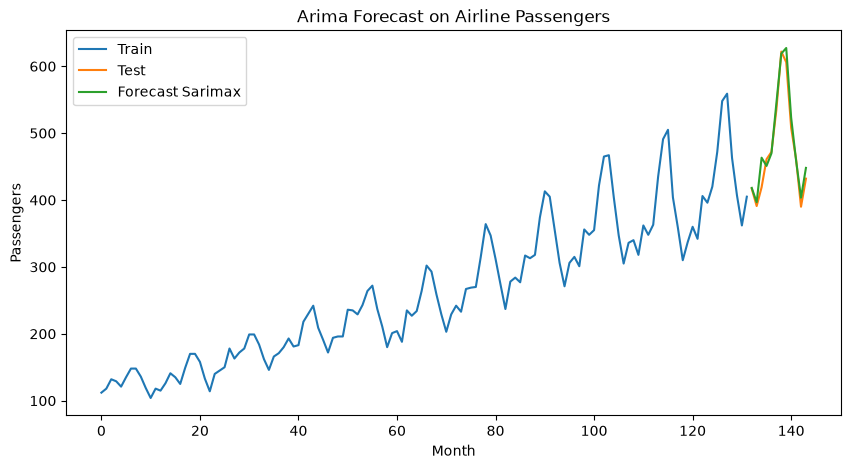

In [36]:
plt.figure(figsize=(10,5))
plt.plot(train.index,train["Passengers"],label="Train")
plt.plot(test.index,test["Passengers"],label="Test")
plt.plot(test.index,forecast_sarimax,label="Forecast Sarimax")
plt.title("Arima Forecast on Airline Passengers")
plt.xlabel("Month")
plt.ylabel("Passengers")
plt.legend()
plt.show()


In [37]:
mse=mean_squared_error(test['Passengers'],forecast_sarimax)
mae=mean_absolute_error(test["Passengers"],forecast_sarimax)
rmse=root_mean_squared_error(test["Passengers"],forecast_sarimax)
print(f"MSE: {mse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")


MSE: 277.41
MAE: 11.99
RMSE: 16.66


### Export Model Artifacts for Deployment


In [ ]:
import joblib

# Export trained SARIMAX model
joblib.dump(trained_sarimax_model, 'model.joblib')
print("Forecast model successfully saved to model.joblib")
